### Данные: Wildberries API, категория "Ноутбуки" (subjectId=2290), июнь 2026, 1400 товаров.

## Цель проекта:
#### Анализ конкурентной среды в категории "Ноутбуки" на Wildberries — для понимания структуры рынка, ценовых сегментов и поведения поставщиков.

## Импорт, EDA

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/datasets/tslava74/wildberries-an/wb_notebooks_v2.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(1400, 11)
id                   int64
name                object
brand               object
supplier            object
supplier_rating    float64
rating               int64
review_rating      float64
feedbacks            int64
price_basic        float64
price_sale         float64
discount_pct       float64
dtype: object
id                   0
name                 0
brand              222
supplier             0
supplier_rating      0
rating               0
review_rating        0
feedbacks            0
price_basic          0
price_sale           0
discount_pct         0
dtype: int64
                 id  supplier_rating       rating  review_rating    feedbacks  \
count  1.400000e+03      1400.000000  1400.000000    1400.000000  1400.000000   
mean   8.144041e+08         4.742929     3.026429       2.985071    49.412857   
std    2.320834e+08         0.206558     2.379929       2.345421   216.846802   
min    1.595868e+08         3.700000     0.000000       0.000000     0.000000   
25%    

## Q1: What is the price distribution? — Как распределены цены?

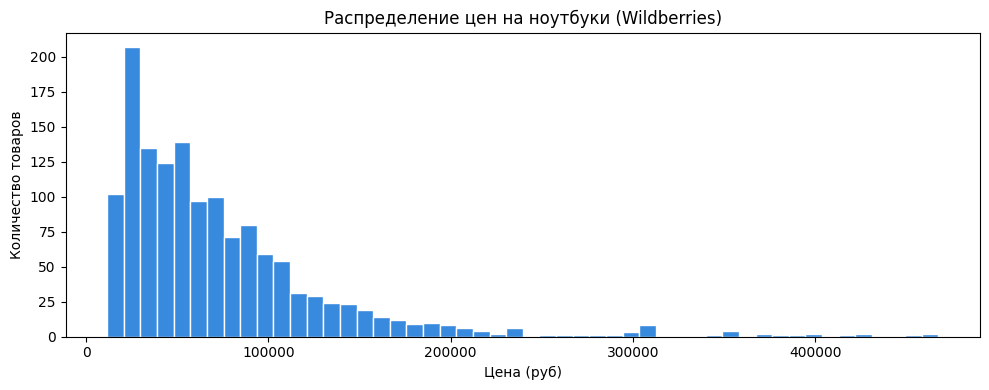

count      1398.0
mean      73964.0
std       61814.0
min       11508.0
25%       31486.0
50%       56780.0
75%       93056.0
max      467711.0
Name: price_sale, dtype: float64


In [39]:
# фильтруем выбросы — оставляем цены до 500к
df_clean = df[df['price_sale'] <= 500_000].copy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_clean['price_sale'], bins=50, color='#378ADD', edgecolor='white')
ax.set_title('Распределение цен на ноутбуки (Wildberries)')
ax.set_xlabel('Цена (руб)')
ax.set_ylabel('Количество товаров')
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150)
plt.show()

# медиана и квартили — формат результата: числа
print(df_clean['price_sale'].describe().round(0))

#### Инсайт — Как распределены цены на WB  (23 июня 2026)

**Вывод** по распределению цен
Общая характеристика:
В выборке 1 398 товаров
Цены варьируются от 11 508 до 467 711 — разброс очень большой, отброшены цены свыше 500к
Ключевые наблюдения:
Распределение скошено вправо — средняя цена (73 964) заметно выше медианы (56 780). Это значит, что большинство товаров дешевле среднего, а завышают среднее дорогие выбросы.
Большой разброс цен — стандартное отклонение (61 814) почти равно среднему значению. Цены сильно различаются между собой.
Основная масса товаров — 50% товаров имеют цену от ~31 500 до ~93 000 (межквартильный размах).
Наличие выбросов — максимум (467 711) в 5 раз больше Q3 (93 056). Есть единичные очень дорогие товары, которые сильно искажают среднее.

## Q2: Which brands dominate? — Какие бренды доминируют?

In [40]:
df_clean.head()

,id,name,brand,supplier,supplier_rating,rating,review_rating,feedbacks,price_basic,price_sale,discount_pct
0,684352087,Ноутбук игровой Vector 17 HX AI A2XW,MSI,Modern Device,4.8,5,5.0,37,258893.0,199088.0,23.1
1,684148235,Ноутбук игровой Katana 17 B13UCR-1612XRU (9S7-...,MSI,Modern Device,4.8,5,4.9,132,99315.0,76373.0,23.1
2,957182649,Ноутбук Modern 15 F1MG-1072XRU (9S7-15S111-1072),MSI,Modern Device,4.8,0,0.0,0,66312.0,50993.0,23.1
3,968702307,Ноутбук игровой Stealth 16 AI A2HWFG-086XRU (9...,MSI,Modern Device,4.8,5,5.0,2,199228.0,153206.0,23.1
4,950192767,Ноутбук игровой Katana 17 B2RVEK-1617XRU (9S7-...,MSI,Modern Device,4.8,5,4.8,19,116413.0,89521.0,23.1


In [41]:
top_brands = (
    df_clean.groupby('brand')['id']
    .count()
    .sort_values( ascending=False)
    .head(15)
    .reset_index(name='count')
)
top_brands['percent'] = (top_brands['count'] / len(df_clean) * 100).round(1)
print(top_brands)

        brand  count  percent
0        Asus    260     18.6
1       Apple    118      8.4
2      Lenovo    106      7.6
3       HONOR     77      5.5
4         MSI     70      5.0
5        Acer     60      4.3
6    Vicyoung     45      3.2
7      AZERTY     41      2.9
8          HP     28      2.0
9     Ninkear     22      1.6
10  maibenben     20      1.4
11     FRONSH     17      1.2
12     Huawei     17      1.2
13      TECNO     17      1.2
14        PWR     15      1.1


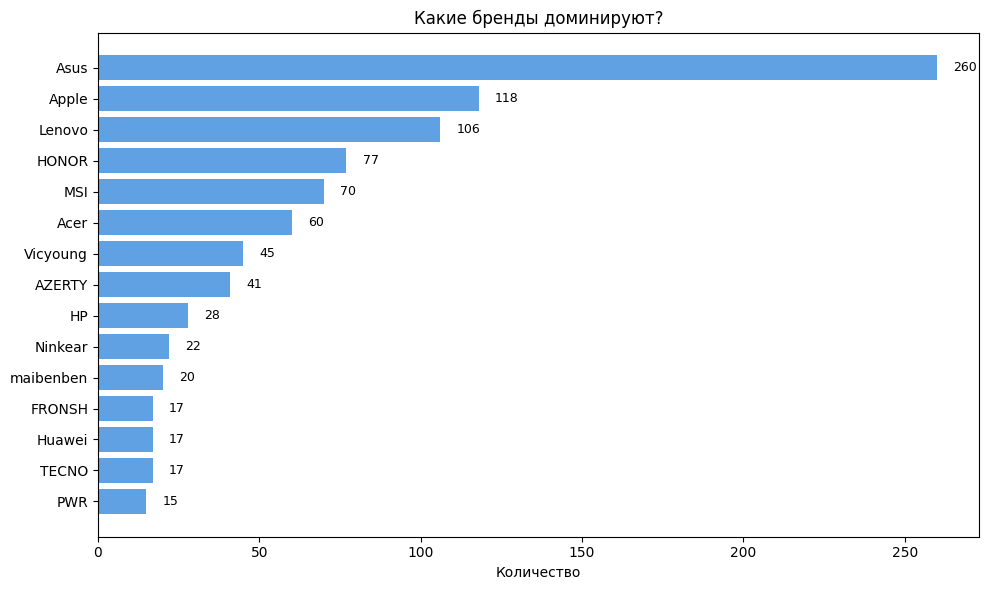

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_brands['brand'][::-1], 
    top_brands['count'][::-1],
    color='#378ADD', alpha=0.8
)

ax.set_xlabel('Количество')
ax.set_title('Какие бренды доминируют?')

for bar in bars:
    ax.text(bar.get_width() + 5, 
            bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('brand_dominance.png', dpi=150)
plt.show()

#### Инсайт — Какие бренды доминируют в предложении на WB  (23 июня 2026)
| Бренды | Количество | % рынка |
|---|---|---|
| Asus| 260 | 18.6% |
| Apple | 118 | 8.4% |
| Lenovo | 106 | 7.6% |
| Honor | 77 | 5.5% |

**Вывод:** Asus доминирует с большим отрывом — 18.6% всех товаров, в 2.2x больше чем Apple на втором месте. Топ-4 бренда занимают 40% рынка. Среди китайских брендов активны HONOR, Vicyoung, AZERTY.
Высокая концентрация топ-4 брендов (40%) означает высокий порог входа для новых игроков. Конкурировать с Asus будет сложно из-за их доминирования.

## Q3: Which brands offer the biggest discounts? — Какие бренды дают самые большие скидки?

In [43]:
top_brands_per_discount = (
    df_clean.groupby('brand')['discount_pct']
    .agg(['mean','count'])
    .query('count >= 10')
    ['mean']
    .round(1)
    .sort_values( ascending=False)
    .head(15)
    .reset_index()
)

print(top_brands_per_discount)

          brand  mean
0      ApexNote  78.0
1           PWR  60.1
2        Xiaomi  44.3
3       Ninkear  42.3
4        AZERTY  41.6
5         HONOR  41.0
6      Vicyoung  37.9
7        FRONSH  37.3
8   Thunderobot  36.2
9          Asus  33.7
10        CHUWI  33.1
11        Apple  31.0
12    maibenben  29.7
13       Lenovo  28.9
14         Acer  27.1


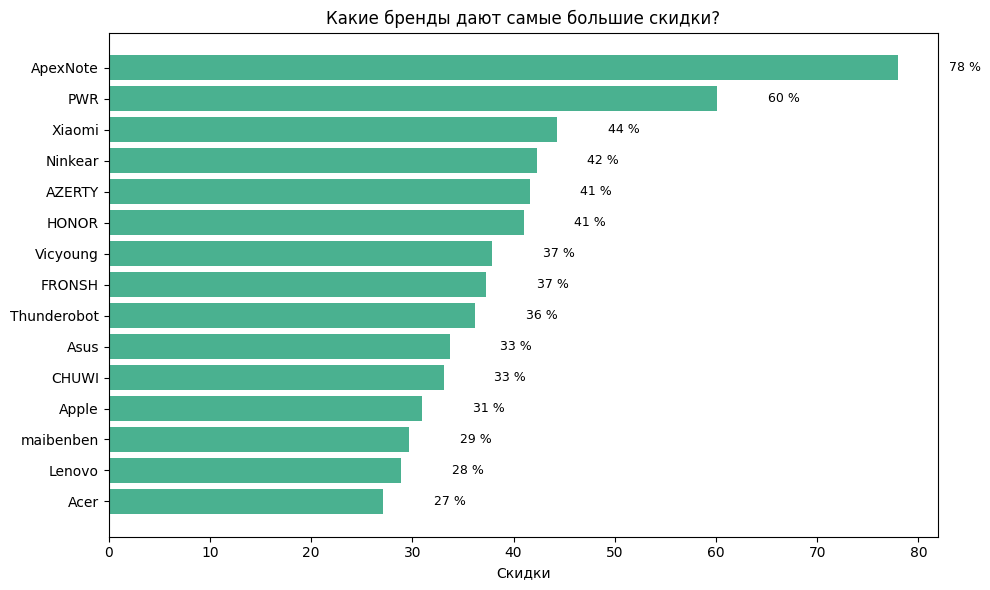

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_brands_per_discount['brand'][::-1], 
    top_brands_per_discount['mean'][::-1],
    color='#1D9E75', alpha=0.8
)

ax.set_xlabel('Скидки')
ax.set_title('Какие бренды дают самые большие скидки?')

for bar in bars:
    ax.text(bar.get_width() + 5, 
            bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())} %', 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('brand_discounts.png', dpi=150)
plt.show()

##### Инсайт — Бренды у которых более 10 предложений, дающие существенные скидки на WB  (23 июня 2026)
| Бренды | % скидка |
|---|---|
| ApexNote| 78.0% |
| PWR | 60.1% |
| Xiaomi | 44.3% |
| Ninkear | 42.3% |

**Вывод:** Лидеры среди предложений по товаром предлагаю скидки на уровне 25- 45%, есть более существенные скидки от малоизвестных брендов с небольшим предложением товара.
Лидеры рынка дают скидки 44-78%, но у малоизвестных брендов скидки могут быть еще выше (до 78%). Это их стратегия привлечения внимания.

## Q4: Does discount correlate with feedbacks? — Скидка связана с количеством отзывов?

In [45]:
discount_from_feedbacks = df_clean['discount_pct'].corr(df_clean['feedbacks'])



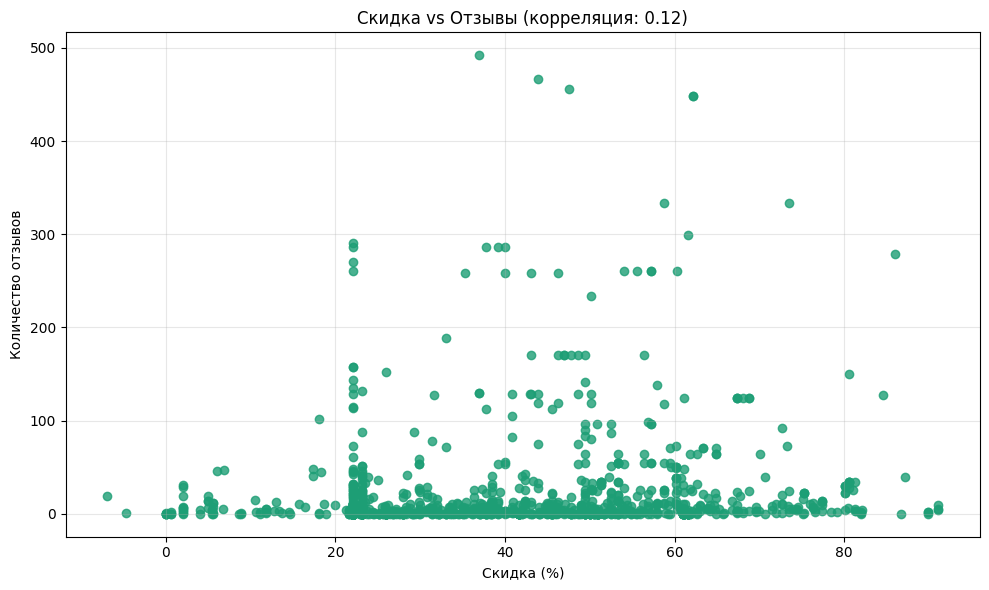

In [46]:
df_filtered = df_clean[df_clean['feedbacks'] <= 500]

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_filtered['discount_pct'], 
    df_filtered['feedbacks'],
    color='#1D9E75', alpha=0.8
)

ax.set_xlabel('Скидка (%)')
ax.set_ylabel('Количество отзывов')
ax.set_title(f'Скидка vs Отзывы (корреляция: {discount_from_feedbacks:.2f})')
ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('discount_from_feedbacks.png', dpi=150)
plt.show()

##### Инсайт — Связана ли скидка с колличеством отзывов на WB  (23 июня 2026)


**Вывод:** Наблюдается очень слабая положительная корреляция - 0,12, что говорит почти об отсутствии между скидкой и количеством отзывов. \
Продавцы устанавливают скидки независимо от популярности товара.

## Q5: Which price segments are most competitive? — Какой сегмент самый конкурентный?

In [47]:
# pd.cut() делит числовую колонку на диапазоны — результат: новая колонка segment
bins = [0, 30000, 60000, 100000, 200000, 500000]
labels = ['до 30к', '30-60к', '60-100к', '100-200к', '200к+']

df_clean['segment'] = pd.cut(df_clean['price_sale'], bins=bins, labels=labels)

In [48]:
top_segment = (
    df_clean.groupby('segment', observed=True)['price_sale']
    .count()
    .sort_values( ascending=False)
    .reset_index(name='count')
)
top_segment['percent'] = (top_segment['count'] / len(df_clean) * 100).round(1)
print(top_segment)

    segment  count  percent
0    30-60к    436     31.2
1   60-100к    354     25.3
2    до 30к    310     22.2
3  100-200к    247     17.7
4     200к+     51      3.6


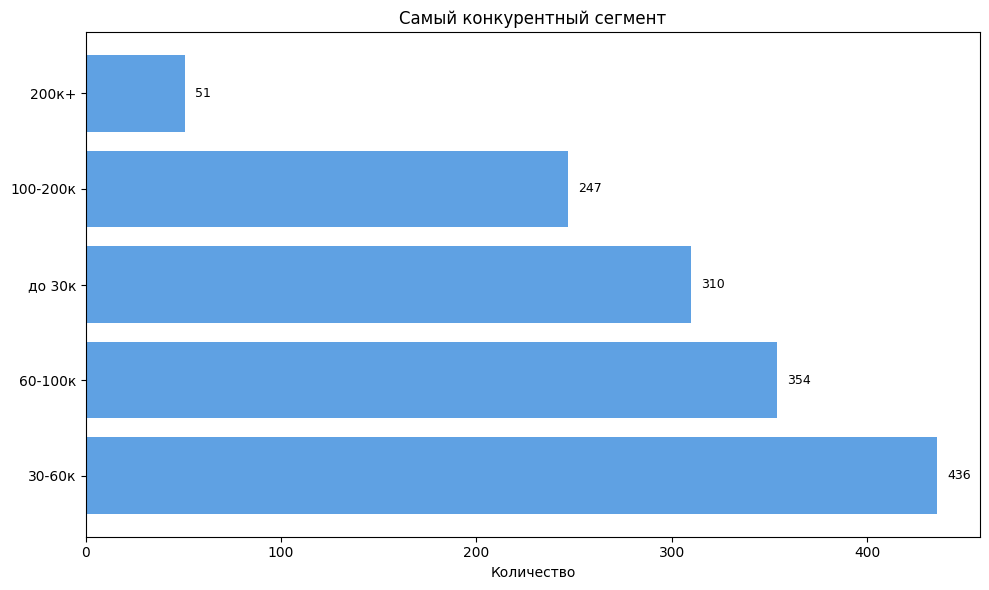

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_segment['segment'], 
    top_segment['count'],
    color='#378ADD', alpha=0.8
)

ax.set_xlabel('Количество')
ax.set_title('Самый конкурентный сегмент')

for bar in bars:
    ax.text(bar.get_width() + 5, 
            bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_segment.png', dpi=150)
plt.show()

##### Инсайт — Какой сегмент самый конкурентный на WB  (23 июня 2026)
| Сегмент | Предложения | % рынка |
|---|---|---|
| 30-60к | 436 | 31.2% |
| 60-100к | 354 | 25.3% |
| до 30к | 310 | 22.2% |
| 100-200к | 247 | 17.7% |
| 200к+ | 51 | 3.6 |

**Вывод:** Спрос рождает предложение \
Лидеры (30-60к) модели середнички (соотношение цена+качество) для покупателей которые уже знакомы с ПК \
Для определенного вида работ на ПК нужны уже более бодрые модели 60-100к 
А вот для знакомстваили или как первый компьютер (в подарок) до 30К 
Игровые и професиональные модели присутствуют на рынки, но в меньшем количестве.

## Q6: Do higher-rated products cost more? — Дорогие товары имеют рейтинг выше?

In [50]:
price_sale_from_review_rating = df_clean['price_sale'].corr(df_clean['review_rating'])
price_sale_from_review_rating

np.float64(-0.24161086368405185)

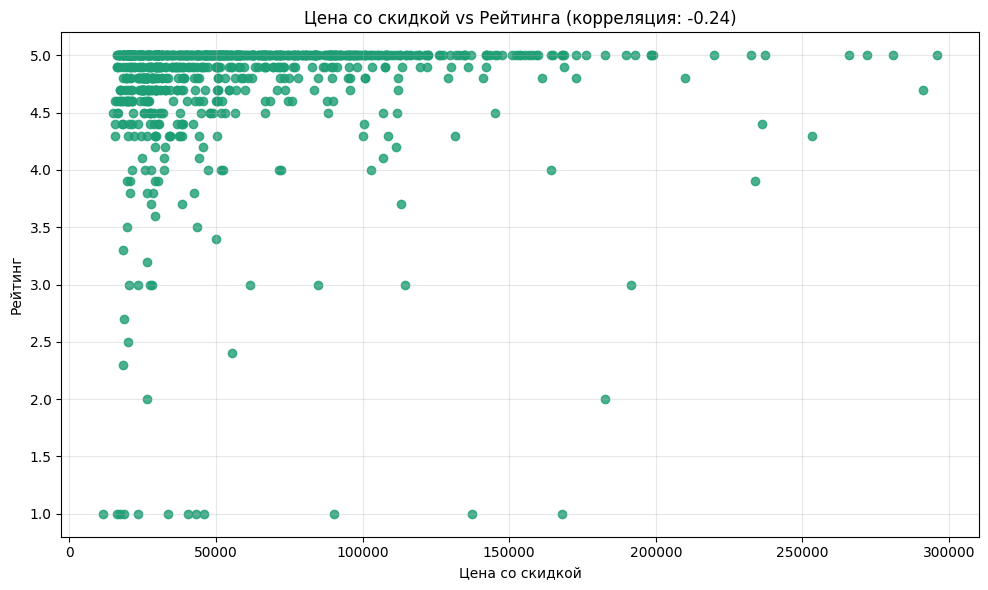

In [51]:
df_fil = df_clean[(df_clean['review_rating'] >= 1) & (df_clean['price_sale'] <= 300000)]

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_fil['price_sale'], 
    df_fil['review_rating'],
    color='#1D9E75', alpha=0.8
)

ax.set_xlabel('Цена со скидкой')
ax.set_ylabel('Рейтинг')
ax.set_title(f'Цена со скидкой vs Рейтинга (корреляция: {price_sale_from_review_rating:.2f})')
ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('price_sale_from_review_rating.png', dpi=150)
plt.show()

##### Инсайт — "Дорогие товары имеют рейтинг выше" так ли это на WB  (23 июня 2026)

**Вывод:** Корреляция -0.24 говорит о слабой отрицательной связи между ценой со скидкой Ценой со скидкой и рейтингом. \
И опровергает частично гипотезу что дорогие товары имеют высокий рейтинг.


## Q7: What % of products have no reviews? — Сколько товаров без отзывов?

In [55]:
no_reviews = df_clean[df_clean['feedbacks'] == 0]
count = len(no_reviews)
percent = round(count / len(df_clean) * 100, 1)
print(f'Товаров без отзывов: {count} ({percent}%)')

Товаров без отзывов: 519 (37.1%)


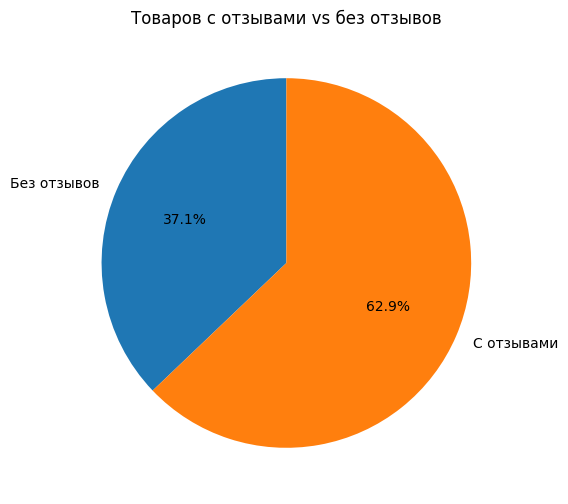

In [60]:
no_reviews = len(df_clean[df_clean['feedbacks'] == 0])
with_reviews = len(df_clean) - no_reviews

plt.figure(figsize=(6, 6))
plt.pie(
    [no_reviews, with_reviews], 
    labels=['Без отзывов', 'С отзывами'], 
    autopct='%1.1f%%', 
    startangle=90
)
plt.title('Товаров с отзывами vs без отзывов')
plt.show()

##### Инсайт — "Сколько товаров без отзывов" на WB  (23 июня 2026)

**Вывод:** Более 1/3 товаров в категории "Ноутбук" не имеет отзывов, которые еще не зарекомендовали себя, что бы прнять по ним решения "к покупке".
Это означает, что покупатели не могут оценить качество ~33% товаров. Для новых продавцов это возможность — товары с хорошими отзывами будут иметь преимущество.

## Q8: Which suppliers have the most listings? — Какие поставщики лидируют?

In [61]:
top_supplier = (
    df_clean.groupby('supplier')['id']
    .count()
    .sort_values( ascending=False)
    .head(15)
    .reset_index(name='count')
)
top_supplier['percent'] = (top_supplier['count'] / len(df_clean) * 100).round(1)
print(top_supplier)

             supplier  count  percent
0         Wildberries     92      6.6
1       Modern Device     72      5.2
2      ХОБОТ ДОСТАВИТ     71      5.1
3      ОНЛАЙНТРЕЙД.РУ     29      2.1
4            СИТИЛИНК     27      1.9
5              HiGeek     25      1.8
6           ДисМаркет     25      1.8
7                 RTK     24      1.7
8                R2D2     24      1.7
9         Ноутбуки ТК     23      1.6
10    КомпьютерМаркет     23      1.6
11                Che     21      1.5
12  СИТИЛИНК Доставка     20      1.4
13         Комп-Бутик     19      1.4
14          Comp Comp     19      1.4


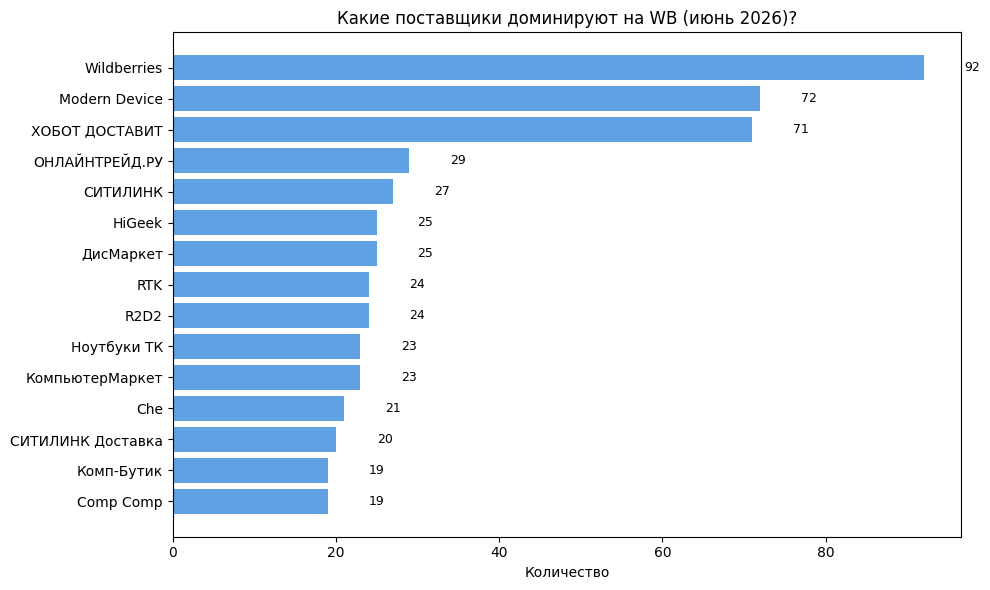

In [62]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_supplier['supplier'][::-1], 
    top_supplier['count'][::-1],
    color='#378ADD', alpha=0.8
)

ax.set_xlabel('Количество')
ax.set_title('Какие поставщики доминируют на WB (июнь 2026)?')

for bar in bars:
    ax.text(bar.get_width() + 5, 
            bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('supplier_dominance.png', dpi=150)
plt.show()

##### Инсайт — Какие поставщики лидируют на WB  (23 июня 2026)
| Поставщик | Предложения | % рынка |
|---|---|---|
| Wildberries  | 92 | 6.6% |
| Modern Device | 72 | 5.2% |
| ХОБОТ ДОСТАВИТ | 71 | 5.1% |
| ОНЛАЙНТРЕЙД.РУ | 29 | 2.1% |

**Вывод:** Рынок фрагментирован — нет доминирующего поставщика, что создает возможности для новых игроков.
Не удивительно, но лидер Wildberries, не обсолютный, но 6,6% доля его поставок\
Modern Device 5,2% и ХОБОТ ДОСТАВИТ 5,1% не сильно отстали от лидера \
Остальные участники рынка имеют доли от 1,4%-2,1%.

## Итоговое резюме

* Рынок ноутбуков на WB характеризуется:
* Доминированием Asus (18.6%) и концентрацией 40% рынка у топ-4 брендов
* Ценовым сегментом 30-60к как самым конкурентным (31.2%)
* Фрагментированным рынком поставщиков — нет доминирующего поставщика
* Слабой связью между скидками, ценами и рейтингами — покупатели выбирают по другим критериям